In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

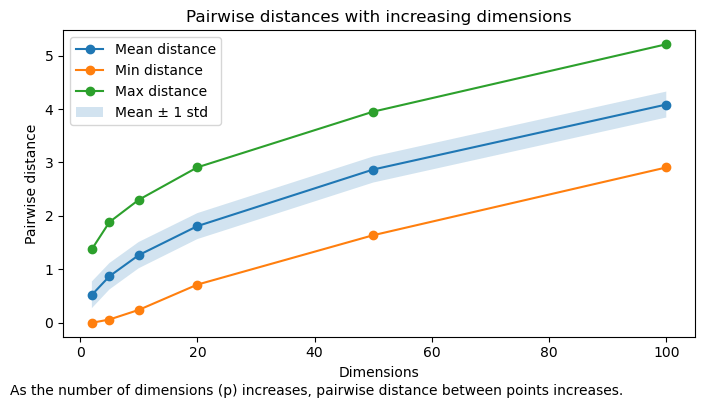

<Figure size 432x288 with 0 Axes>

In [36]:
dims = [2, 5, 10, 20, 50, 100]
num_samples = 1000
rng = np.random.default_rng(42)

mean_dists = []
std_dists = []
min_dists = []
max_dists = []
rel_spread = []

for d in dims:
    data = rng.random((num_samples, d))

    # Pairwise distances using broadcasting; keep upper triangle only.
    dists = pdist(data, metric="euclidean")

    mean_dists.append(np.mean(dists))
    std_dists.append(np.std(dists))
    min_dists.append(np.min(dists))
    max_dists.append(np.max(dists))
    rel_spread.append((np.max(dists) - np.min(dists))/np.mean(dists))

plt.figure(figsize=(7, 4), dpi=100)
plt.plot(dims, mean_dists, marker="o", label="Mean distance")
plt.plot(dims, min_dists, marker="o", label="Min distance")
plt.plot(dims, max_dists, marker="o", label="Max distance")
plt.fill_between(
    dims,
    np.array(mean_dists) - np.array(std_dists),
    np.array(mean_dists) + np.array(std_dists),
    alpha=0.2,
    label="Mean ± 1 std",
)
plt.xlabel("Dimensions")
plt.ylabel("Pairwise distance")
plt.title("Pairwise distances with increasing dimensions")
plt.legend()
plt.figtext(0,0, "As the number of dimensions (p) increases, pairwise distance between points increases.")
plt.tight_layout()
plt.show()

plt.savefig("manali_CoD.png", dpi=300)


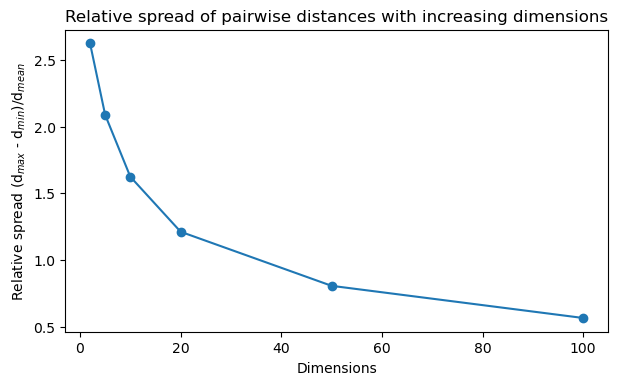

In [38]:
plt.figure(figsize=(7, 4), dpi=100)
plt.plot(dims, rel_spread, marker="o", label="Relative spread")
plt.ylabel("Relative spread (d$_{max}$ - d$_{min}$)/d$_{mean}$")
plt.xlabel("Dimensions")
plt.title("Relative spread of pairwise distances with increasing dimensions")
plt.savefig("Manali_CoD_rel_spread.png", dpi=300)

In [35]:
for d, mn, sd, min, max, rel in zip(dims, mean_dists, std_dists, min_dists, max_dists, rel_spread):
    print(
        f"d={d:3d} | mean={mn:.3f} std={sd:.3f} min={min:.3f} max={max:.3f} rel_spread={rel:.3f}"
    )

d=  2 | mean=0.525 std=0.250 min=0.001 max=1.379 rel_spread=2.626
d=  5 | mean=0.872 std=0.247 min=0.063 max=1.886 rel_spread=2.090
d= 10 | mean=1.268 std=0.246 min=0.243 max=2.302 rel_spread=1.625
d= 20 | mean=1.810 std=0.243 min=0.716 max=2.910 rel_spread=1.212
d= 50 | mean=2.869 std=0.244 min=1.640 max=3.951 rel_spread=0.806
d=100 | mean=4.084 std=0.243 min=2.907 max=5.212 rel_spread=0.564
